In [13]:
import pandas as pd
from pathlib import Path
import json
import gzip
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [14]:
#%matplotlib widget

In [15]:
DATA_FOLDER = "data"
CHARGE_FOLDER = "charge"
STATIONS_FOLDER = "stations"

In [16]:
start_date = "2026-07-10"
end_date = "2026-07-11"

df_charge = pd.read_parquet(
    Path("data/charge/"),
    engine="pyarrow",
    filters=[("DATE", ">=", start_date), ("DATE", "<=", end_date)],
)

df_charge = df_charge.drop('DATE', axis=1) # only used for partitioning
df_charge.sort_values(by=["TIME", "STATION_ID"], inplace=True)
df_charge.head(5)

,STATION_ID,STATUS,TIME
0,CH*AMG*E*4528LP04,Available,2026-07-09 22:00:01
1,CH*ECUE5VJCEJNAVDBZNM2WTS825W6QVS,Unknown,2026-07-09 22:00:01
2,CH*ECUE5VJCEJNAVDBZNM2WTS825W6QVS,Available,2026-07-09 22:00:01
3,CH*ECUER7JYV8RUMDSU8T9A5QKLQTP4CX,Available,2026-07-09 22:00:01
4,CH*360*E31441,Available,2026-07-09 22:00:31


In [17]:
df_charge.memory_usage().sum() / 1024 / 1024 # 2.6 MB/day, acceptable

np.float64(3.412456512451172)

In [18]:
# Load the newest file in the folder ()

stations_path = Path(DATA_FOLDER) / STATIONS_FOLDER 
static_path = Path(DATA_FOLDER) / STATIONS_FOLDER
files = glob.glob(str(static_path / "stations_*.json.gz"))
latest_file = max(files, key=lambda x: Path(x).stat().st_mtime)

with gzip.open(latest_file, "rt", encoding="utf-8") as file:
	stations = json.load(file)["EVSEData"]

In [19]:
# Series of operator IDs to names
ser_operators = pd.Series({operator['OperatorID']: operator['OperatorName'] for operator in stations})
ser_operators.head(5)

CH*SWISSCHARGE    Swisscharge
CH*CCC                   Move
CH*ECU                 eCarUp
CH*FASTNED            Fastned
CH*REP            PLUG N ROLL
dtype: object

In [20]:
# A row for each station
rows = []
for operator in stations:
    for station in operator['EVSEDataRecord']:
        row = station
        row['Operator'] = operator['OperatorID']
        rows.append(row)
df_stations = pd.DataFrame(rows)

df_stations.head(5) # 17512 stations

,AccessibilityLocation,Address,AuthenticationModes,CalibrationLawDataAvailability,ChargingFacilities,ChargingStationNames,DynamicInfoAvailable,HotlinePhoneNumber,HubOperatorID,IsHubjectCompatible,...,LocationImage,SuboperatorName,MaxCapacity,AdditionalInfo,ChargingPoolID,DynamicPowerLevel,HardwareManufacturer,Operator,ChargingPoolId,SubOperatorName
0,OnStreet,"{'HouseNum': '0', 'TimeZone': 'UTC+01:00', 'Ci...","[NFC RFID Classic, REMOTE]",Not Available,"[{'power': 20, 'powertype': 'DC'}, {'power': 2...","[{'lang': 'de', 'value': 'Suissetec Lostorf'}]",true,+41713881150,CH*SWISSCHARGE,True,...,None,None,NaN,None,None,None,None,CH*SWISSCHARGE,NaN,NaN
1,OnStreet,"{'HouseNum': '0', 'TimeZone': 'UTC+01:00', 'Ci...","[NFC RFID Classic, REMOTE]",Not Available,"[{'power': 22, 'powertype': 'AC_3_PHASE'}]","[{'lang': 'de', 'value': 'Suissetec Lostorf'}]",true,+41713881150,CH*SWISSCHARGE,True,...,None,None,NaN,None,None,None,None,CH*SWISSCHARGE,NaN,NaN
2,OnStreet,"{'HouseNum': '0', 'TimeZone': 'UTC+01:00', 'Ci...","[NFC RFID Classic, REMOTE]",Not Available,[],"[{'lang': 'de', 'value': 'Suissetec Lostorf'}]",true,+41713881150,CH*SWISSCHARGE,True,...,None,None,NaN,None,None,None,None,CH*SWISSCHARGE,NaN,NaN
3,OnStreet,"{'HouseNum': '0', 'TimeZone': 'UTC+01:00', 'Ci...","[NFC RFID Classic, REMOTE]",Not Available,[],"[{'lang': 'de', 'value': 'Suissetec Lostorf'}]",true,+41713881150,CH*SWISSCHARGE,True,...,None,None,NaN,None,None,None,None,CH*SWISSCHARGE,NaN,NaN
4,OnStreet,"{'HouseNum': '0', 'TimeZone': 'UTC+01:00', 'Ci...","[NFC RFID Classic, REMOTE]",Not Available,[],"[{'lang': 'de', 'value': 'Suissetec Lostorf'}]",true,+41713881150,CH*SWISSCHARGE,True,...,None,None,NaN,None,None,None,None,CH*SWISSCHARGE,NaN,NaN


## Visualize a particular station

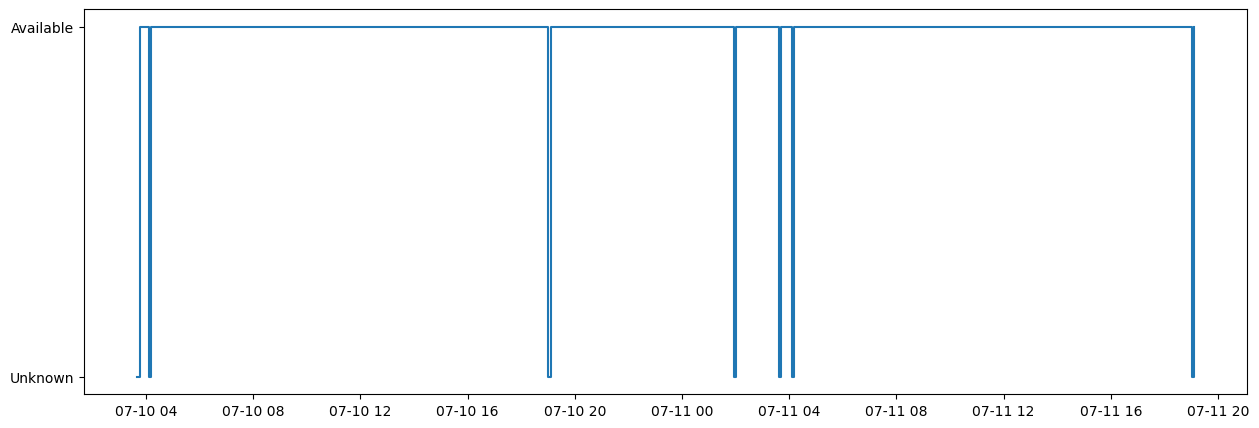

In [21]:
#df_stat = df_charge[df_charge["STATION_ID"] == "+41*029*169*1"]
#df_stat = pd.DataFrame(df_charge[df_charge["STATION_ID"] == "+41*029*1785*2"])
df_stat = pd.DataFrame(df_charge[df_charge["STATION_ID"] == "CH*AVI*E10048"])
df_stat.sort_values("TIME", inplace=True)
fig = plt.figure(figsize=(15, 5))
plt.step(df_stat["TIME"], df_stat["STATUS"], where='post');

## Possible pre-processing step

### Keep in long format and resample

In [22]:
df_charge

,STATION_ID,STATUS,TIME
0,CH*AMG*E*4528LP04,Available,2026-07-09 22:00:01
1,CH*ECUE5VJCEJNAVDBZNM2WTS825W6QVS,Unknown,2026-07-09 22:00:01
2,CH*ECUE5VJCEJNAVDBZNM2WTS825W6QVS,Available,2026-07-09 22:00:01
3,CH*ECUER7JYV8RUMDSU8T9A5QKLQTP4CX,Available,2026-07-09 22:00:01
4,CH*360*E31441,Available,2026-07-09 22:00:31
...,...,...,...
149082,CH*MIG*E*248681,Available,2026-07-11 21:59:15
149083,CH*ECUE5VJCEJNAVDBZNM2WTS825W6QVS,Unknown,2026-07-11 21:59:45
149084,CH*ECUE5VJCEJNAVDBZNM2WTS825W6QVS,Available,2026-07-11 21:59:45
149085,CH*MIG*E*247662,Available,2026-07-11 21:59:45


In [23]:
df_charge[df_charge.duplicated]

,STATION_ID,STATUS,TIME


In [24]:
df_charge_resampled = df_charge.set_index('TIME').groupby('STATION_ID').resample('30s', include_groups=False).ffill().reset_index()
df_charge_resampled.tail(5)

ValueError: cannot reindex on an axis with duplicate labels

In [25]:
# Variant: resample at common time index of all events (best alignment with data collection times)

time_index = (
    df_charge["TIME"]
    .sort_values()
    .unique()
)

df_charge_resampled = (
    df_charge.set_index("TIME")
      .groupby("STATION_ID", group_keys=False)
      .apply(lambda g: g.reindex(time_index).ffill(), include_groups=True)
      .reset_index()
)

df_charge_resampled.tail(5)

ValueError: cannot reindex on an axis with duplicate labels

### Pivot to wide format

In [ ]:
# This automatically set all stations to the same time basis including all measured time steps
df_charge_pvt = df_charge.pivot(index='TIME', columns='STATION_ID', values='STATUS')
df_charge_pvt.ffill(inplace=True) # This is the performance killer somehow!
df_charge_pvt.head(5)

STATION_ID,+41*001*10*1,+41*001*1622*1,+41*001*9*1,+41*002*104*1,+41*002*105*1,+41*002*106*1,+41*002*1065*1,+41*002*107*1,+41*002*1079*1,+41*002*108*1,...,CHFASE4150401,CHFASE4150402,CHFASE4150403,CHFASE4150404,CHFASE4150501,CHFASE4150502,CHFASE4150503,CHFASE4150504,DE*EDH*E001113,DE*EDH*E001114
TIME,,,,,,,,,,,,,,,,,,,,,
2026-01-12 16:35:32,Unknown,Available,Unknown,OutOfService,OutOfService,OutOfService,OutOfService,OutOfService,Available,OutOfService,...,Available,Available,Available,Available,Available,Available,Available,Available,Available,Available
2026-01-12 16:36:01,Unknown,Available,Unknown,OutOfService,OutOfService,OutOfService,OutOfService,OutOfService,Available,OutOfService,...,Available,Available,Available,Available,Available,Available,Available,Available,Available,Available
2026-01-12 16:36:32,Unknown,Available,Unknown,OutOfService,OutOfService,OutOfService,OutOfService,OutOfService,Available,OutOfService,...,Available,Available,Available,Available,Available,Available,Available,Available,Available,Available
2026-01-12 16:37:04,Unknown,Available,Unknown,OutOfService,OutOfService,OutOfService,OutOfService,OutOfService,Available,OutOfService,...,Available,Available,Available,Available,Available,Available,Available,Available,Available,Available
2026-01-12 16:37:32,Unknown,Available,Unknown,OutOfService,OutOfService,OutOfService,OutOfService,OutOfService,Available,OutOfService,...,Available,Available,Available,Available,Available,Available,Available,Available,Available,Available


In [ ]:
df_charge_pvt.memory_usage().sum() / 1024 / 1024 # 1 pivoted day is already 423 MB!

np.float64(423.72125244140625)

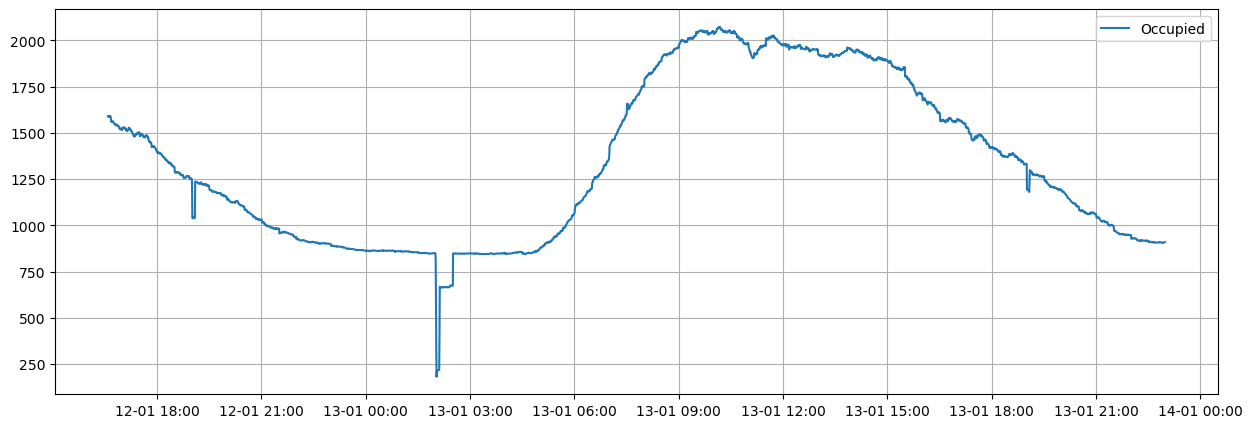

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot((df_charge_pvt == 'Occupied').sum(axis=1), label='Occupied')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
plt.grid()
plt.legend();

## Work in the original long format without resampling

This is way faster but requires custom logic for occupancy calculation

In [ ]:
is_occupied = df_charge["STATUS"].eq("Occupied").astype(int)
df_charge['delta'] = (
    is_occupied
    .groupby(df_charge["STATION_ID"])
    .diff()
    .fillna(is_occupied)
)

In [ ]:
occupied_count = (
    df_charge.groupby("TIME")['delta']
      .sum()
      .cumsum()
)

In [ ]:
df_charge.groupby("TIME")['delta'].sum()

TIME
2026-01-12 16:35:32    1591.0
2026-01-12 16:36:01      -1.0
2026-01-12 16:36:32      -4.0
2026-01-12 16:37:04       3.0
2026-01-12 16:37:32       0.0
                        ...  
2026-01-13 22:55:56      -1.0
2026-01-13 22:57:26       1.0
2026-01-13 22:57:56       0.0
2026-01-13 22:58:27       1.0
2026-01-13 22:58:56       1.0
Name: delta, Length: 3142, dtype: float64

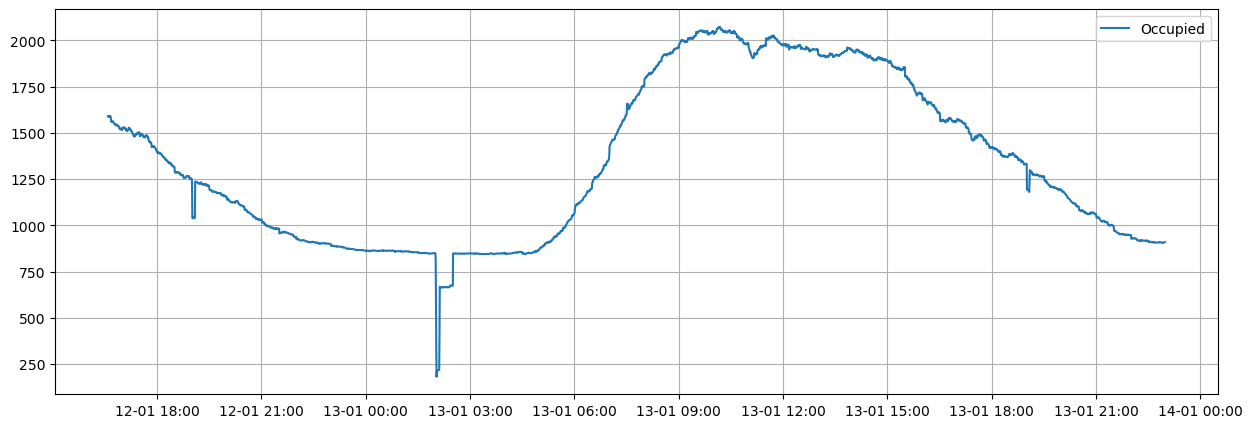

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(occupied_count, label='Occupied')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
plt.grid()
plt.legend();

/var/folders/w7/h67z1rn941j1p0m51k08d9xc0000gp/T/ipykernel_22155/333541861.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(15, 5))


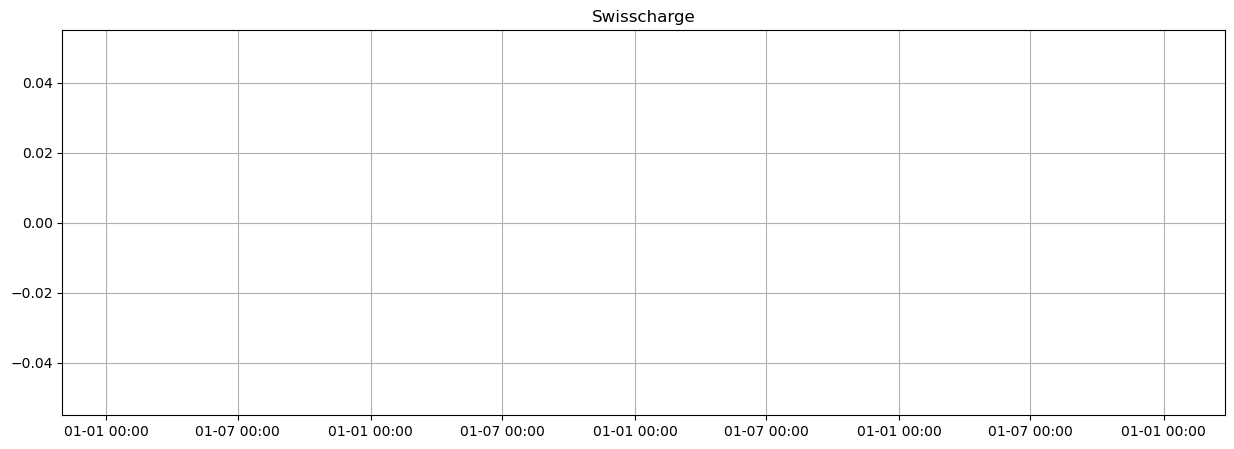

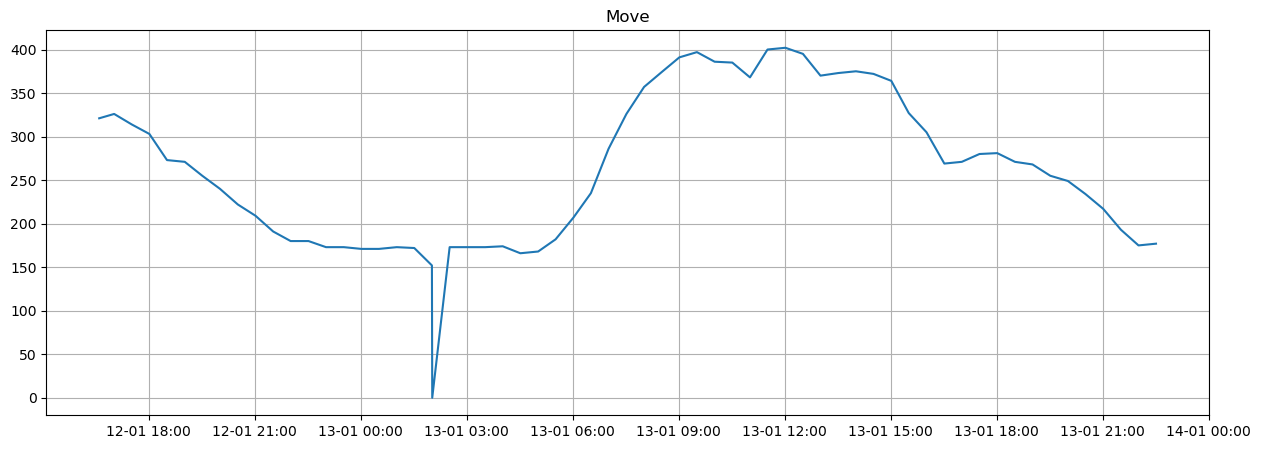

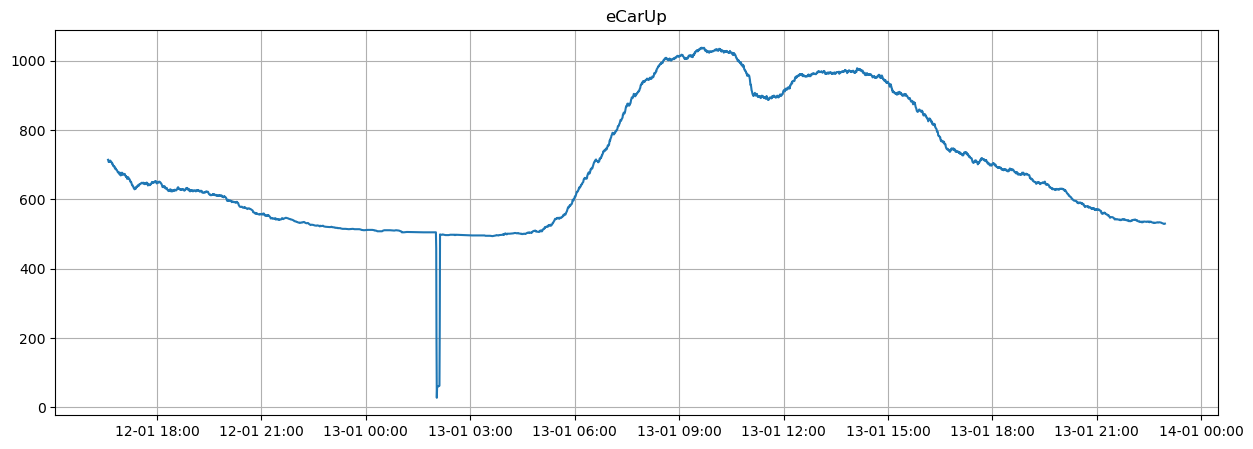

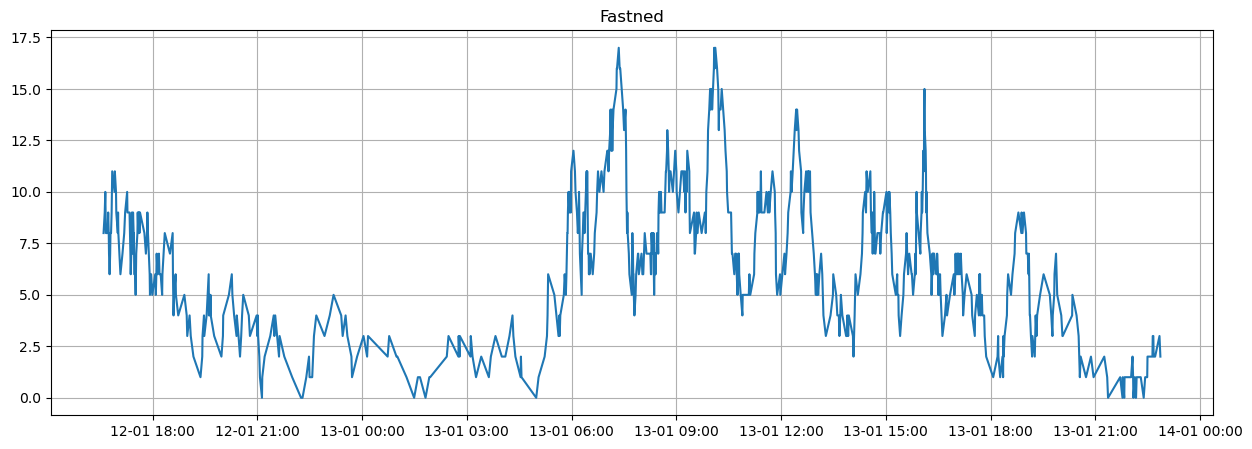

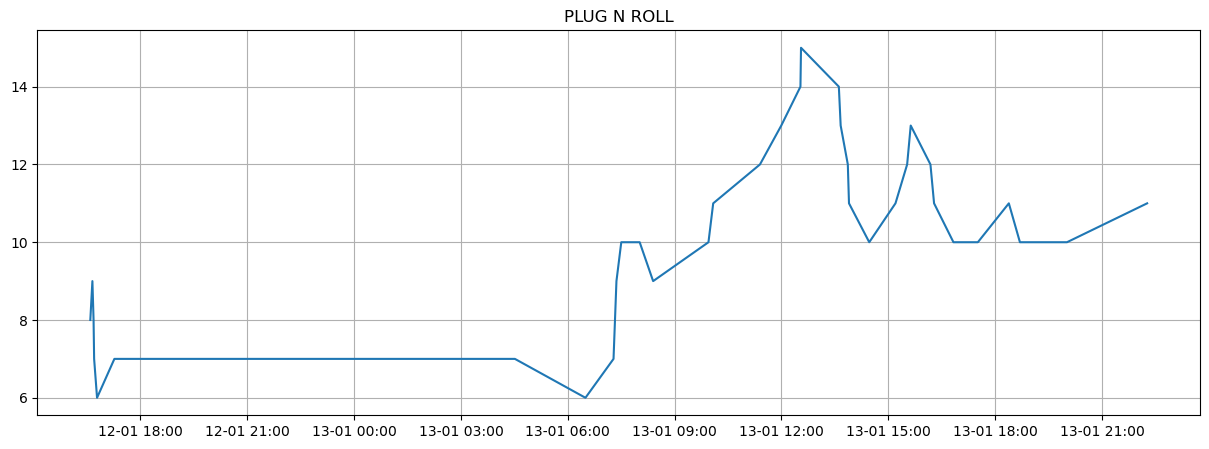

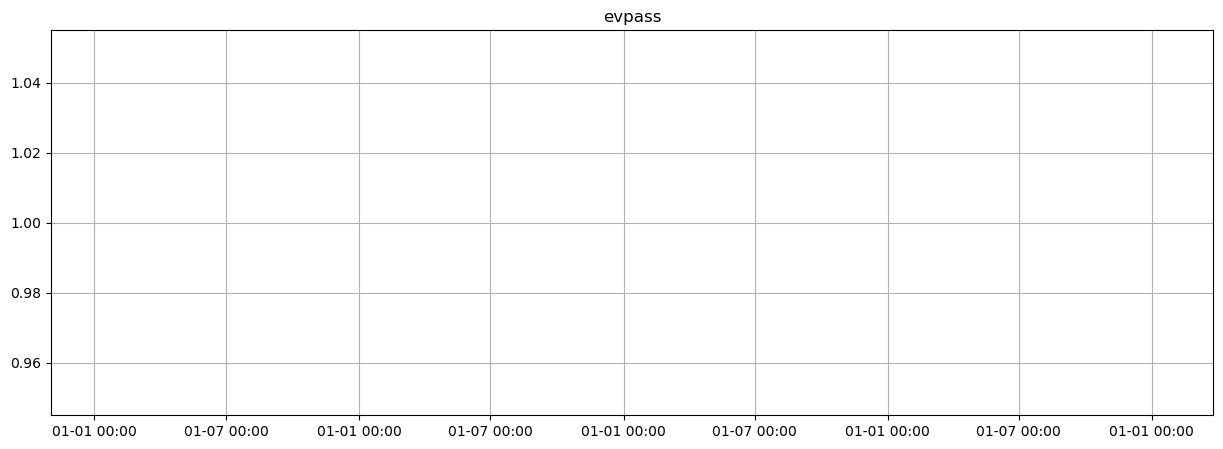

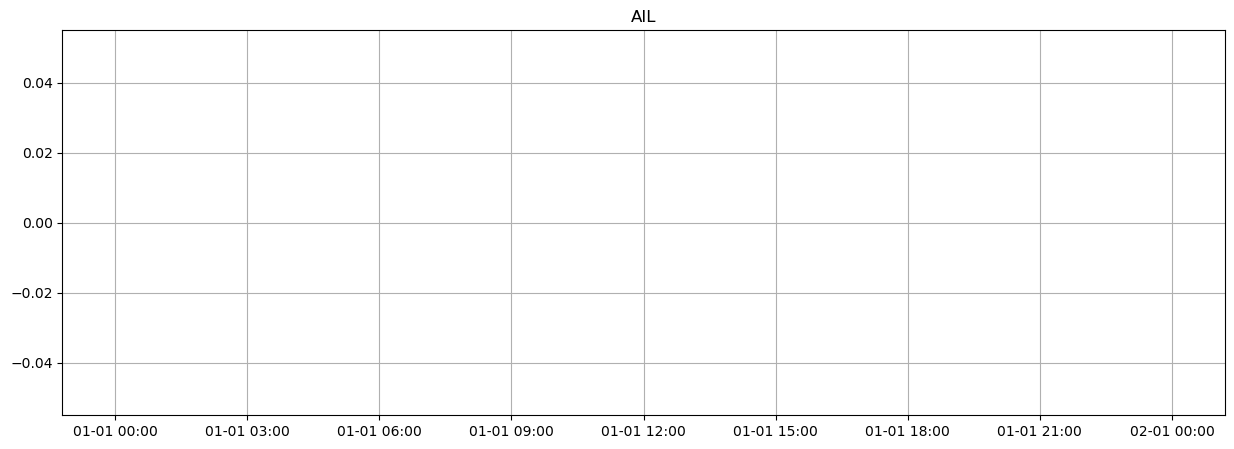

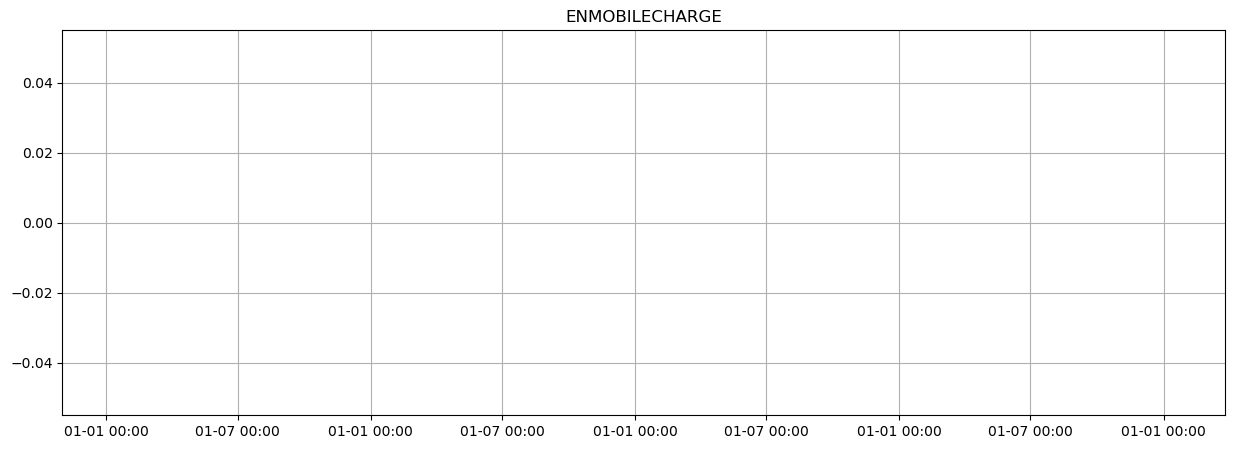

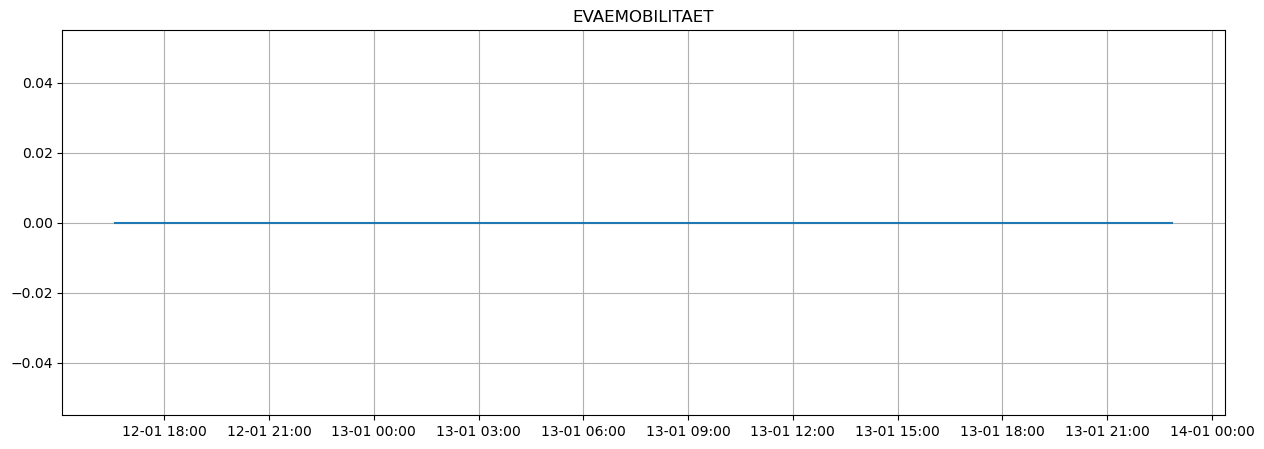

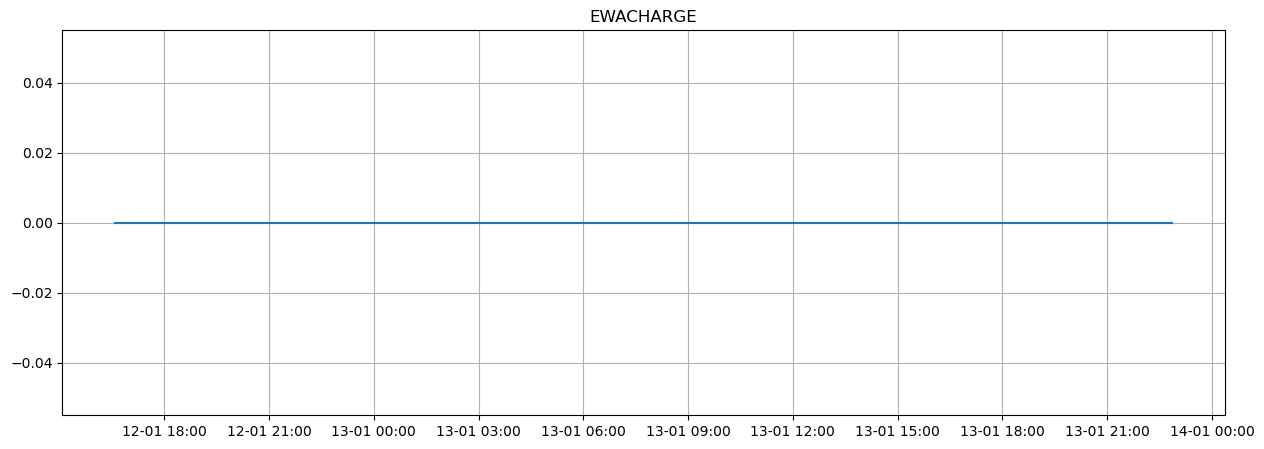

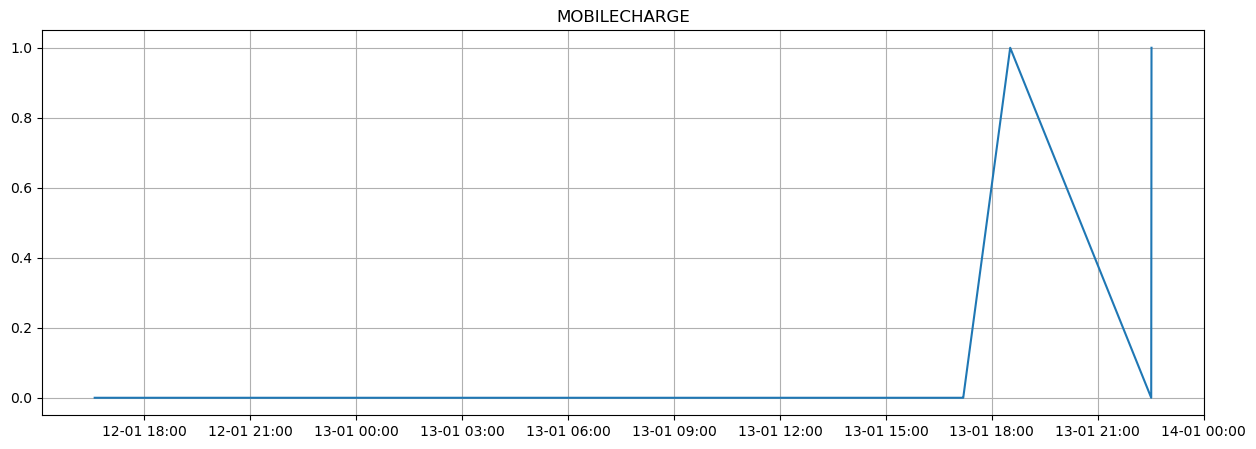

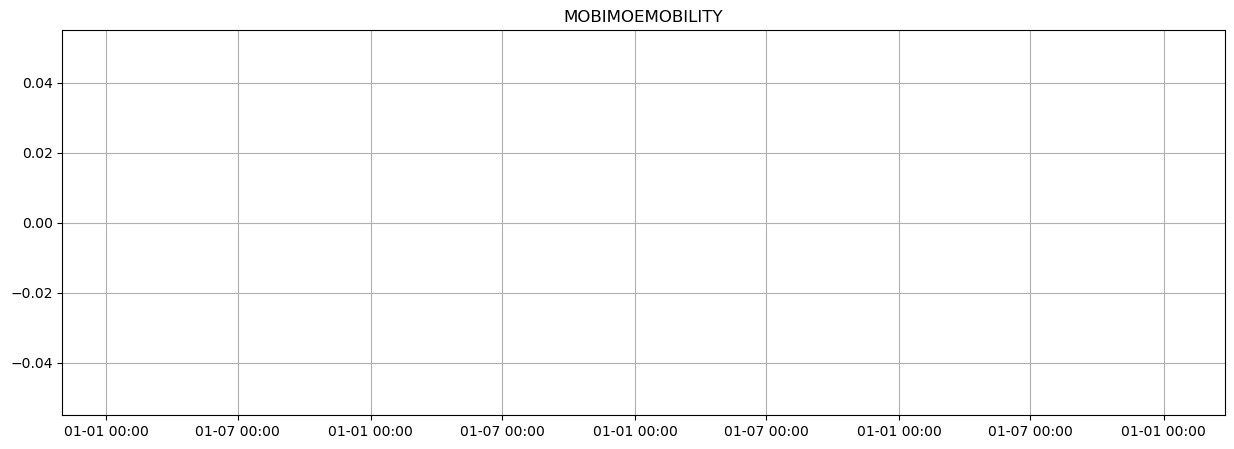

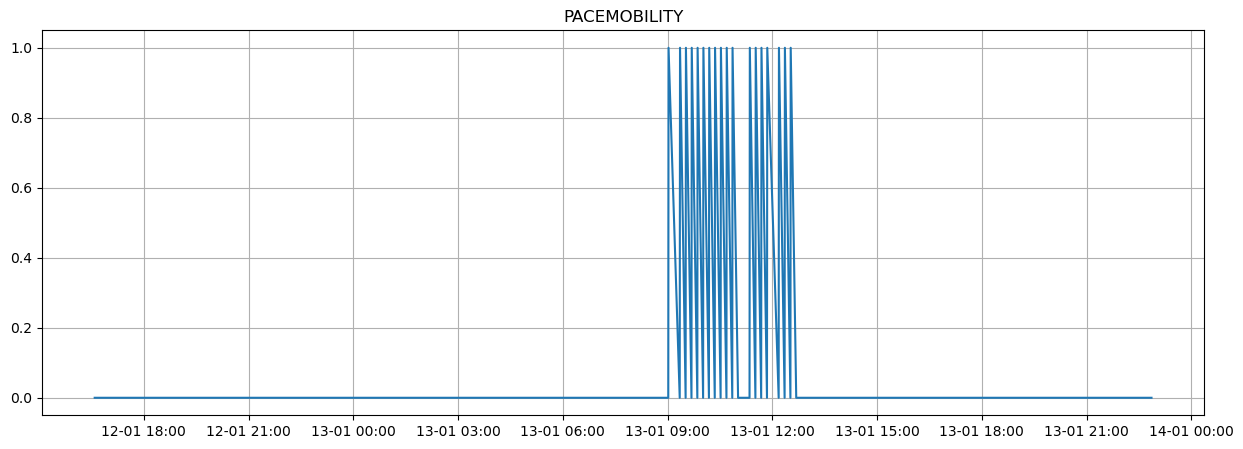

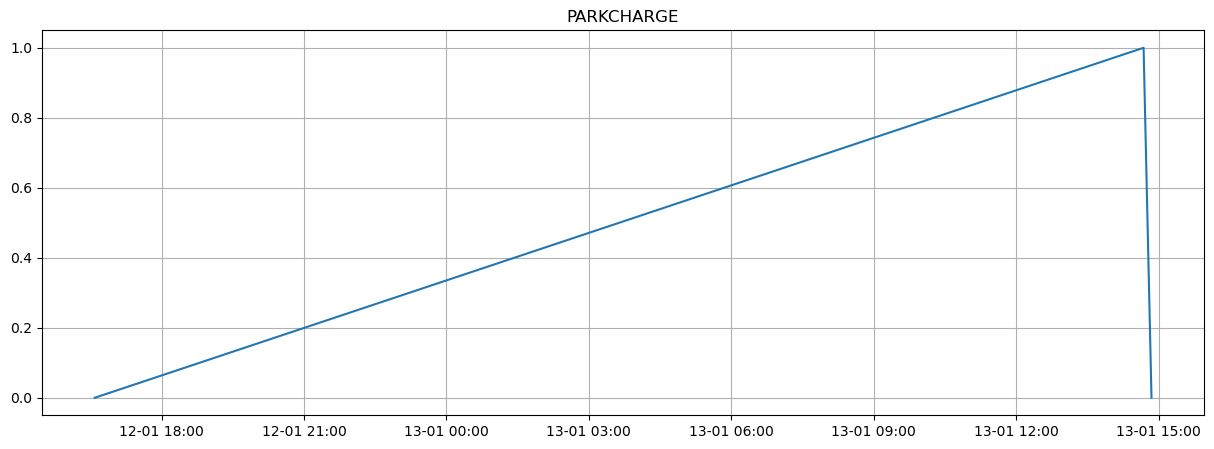

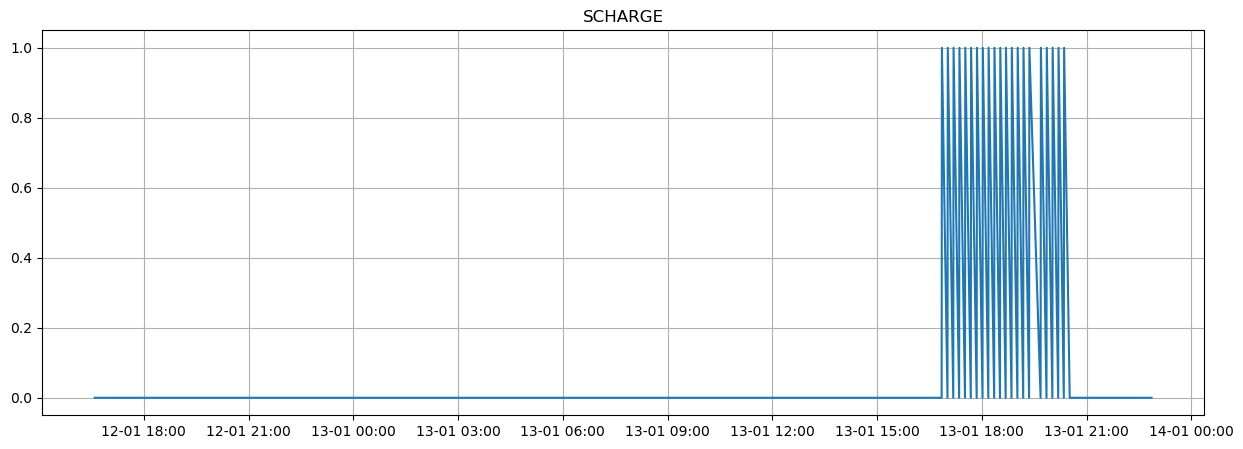

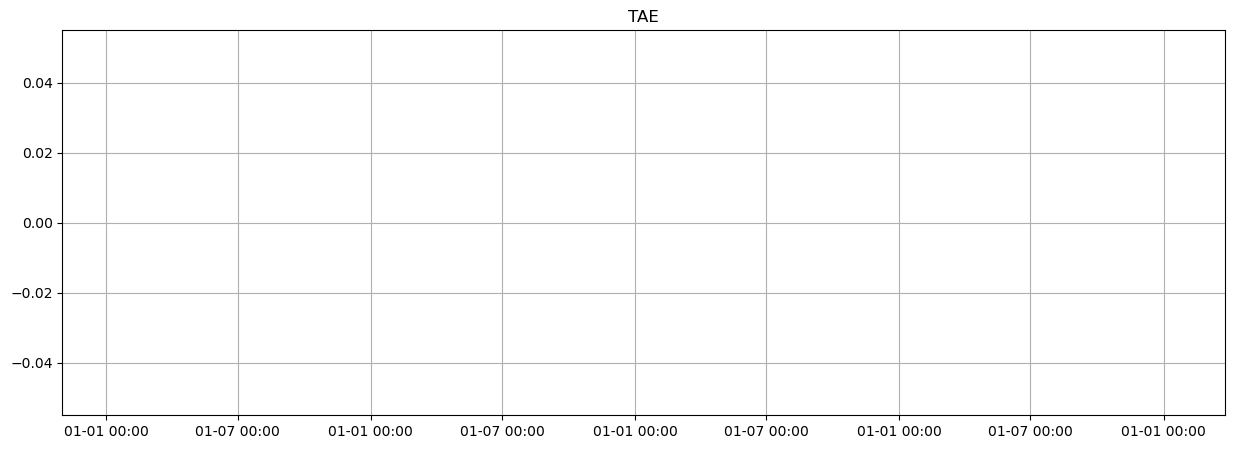

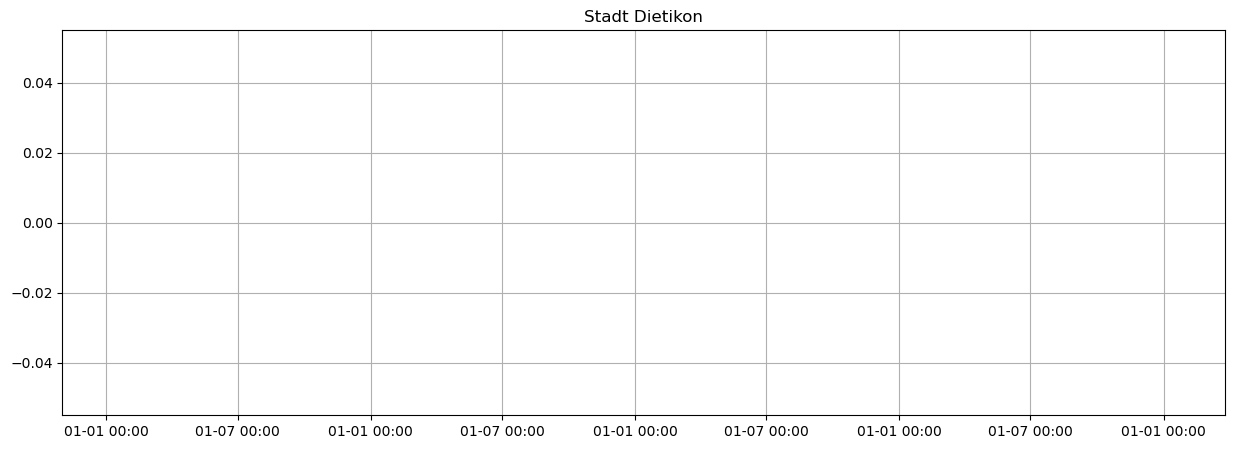

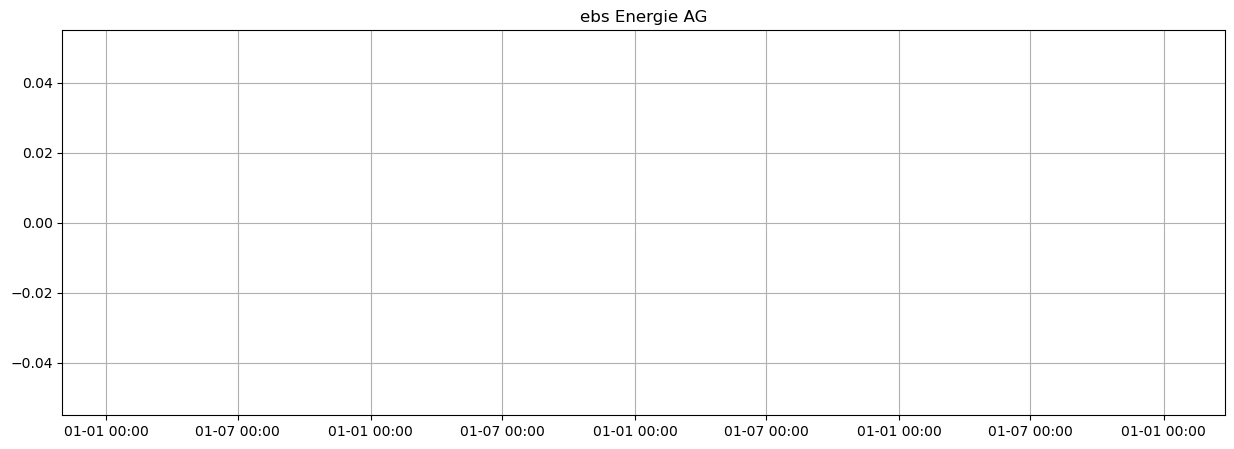

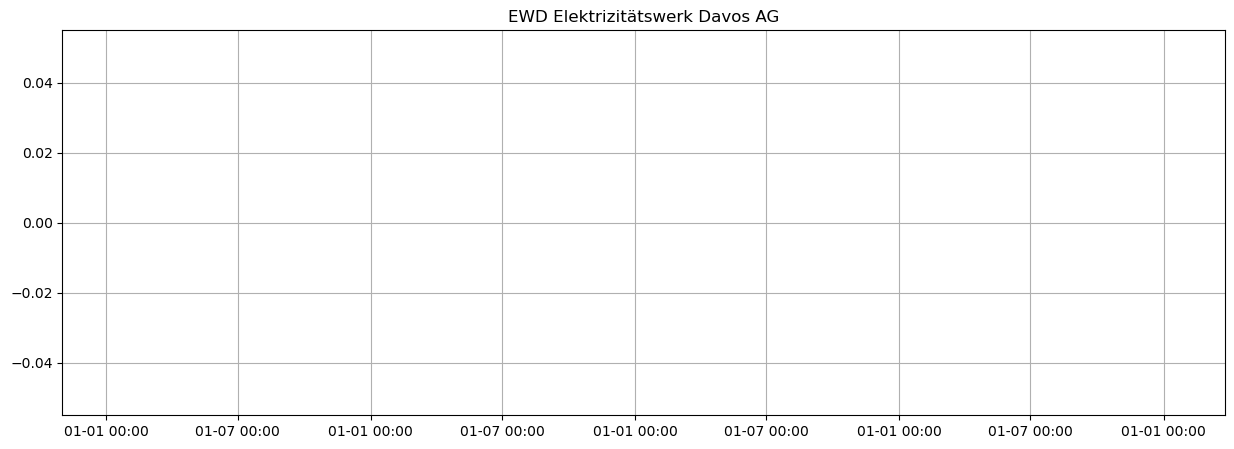

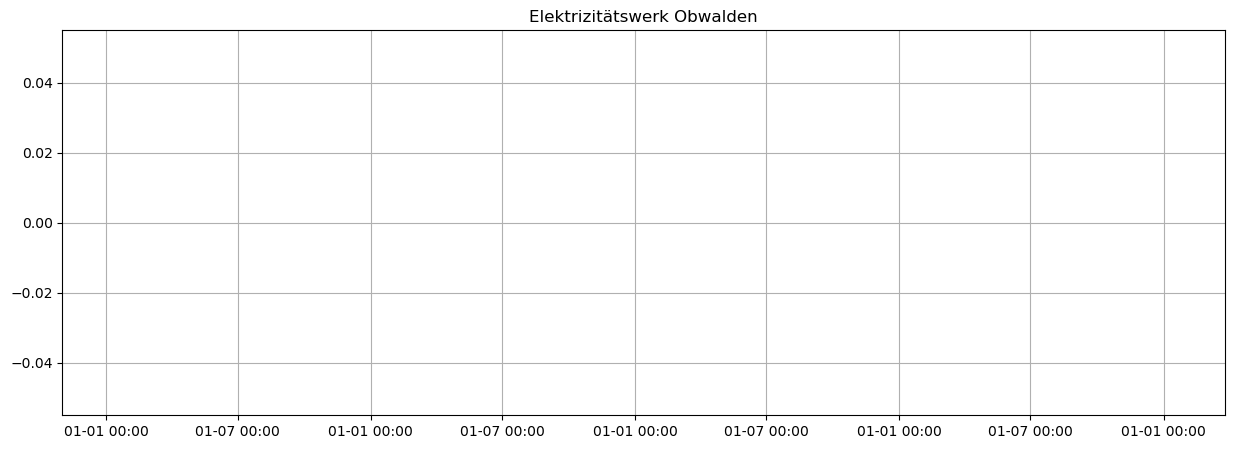

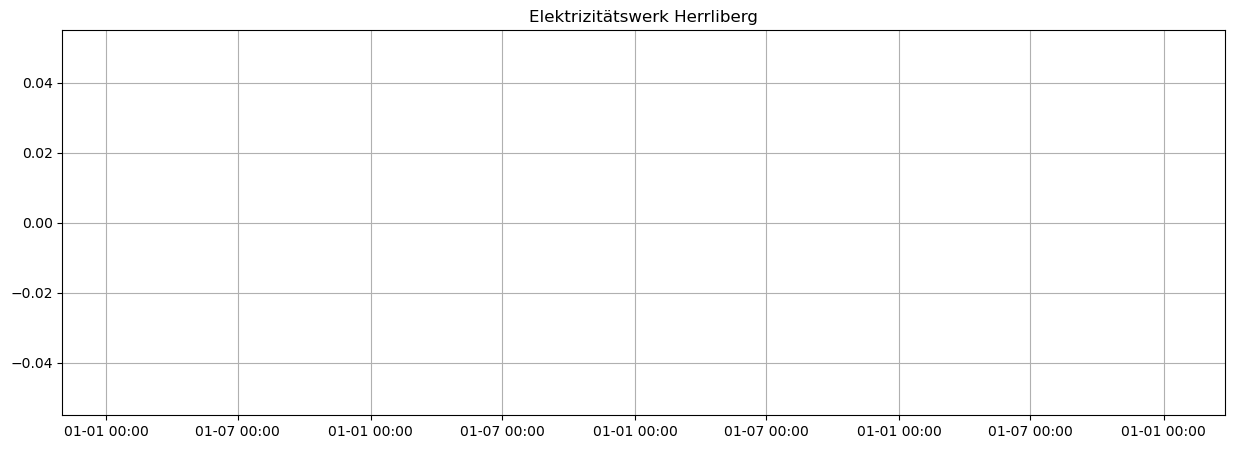

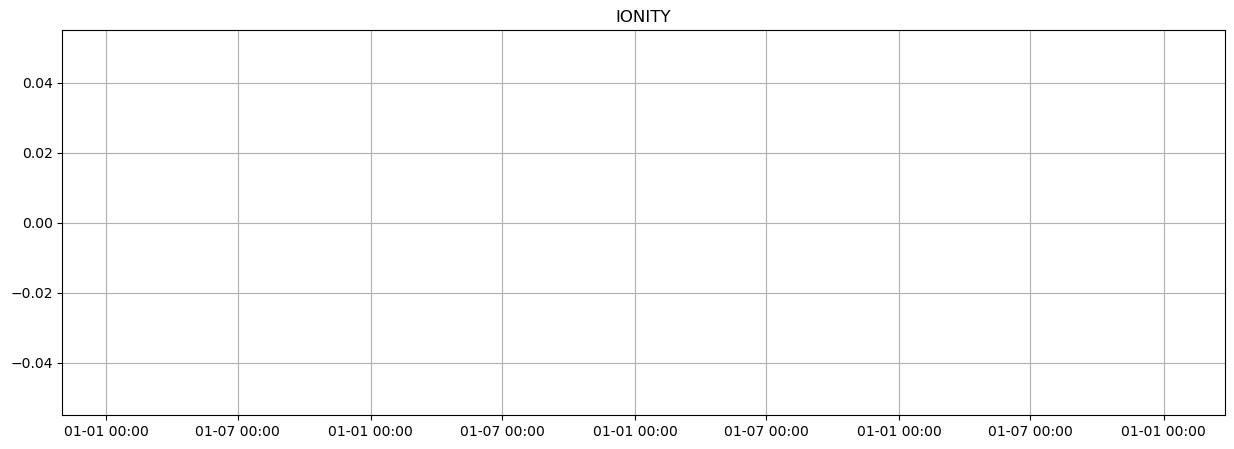

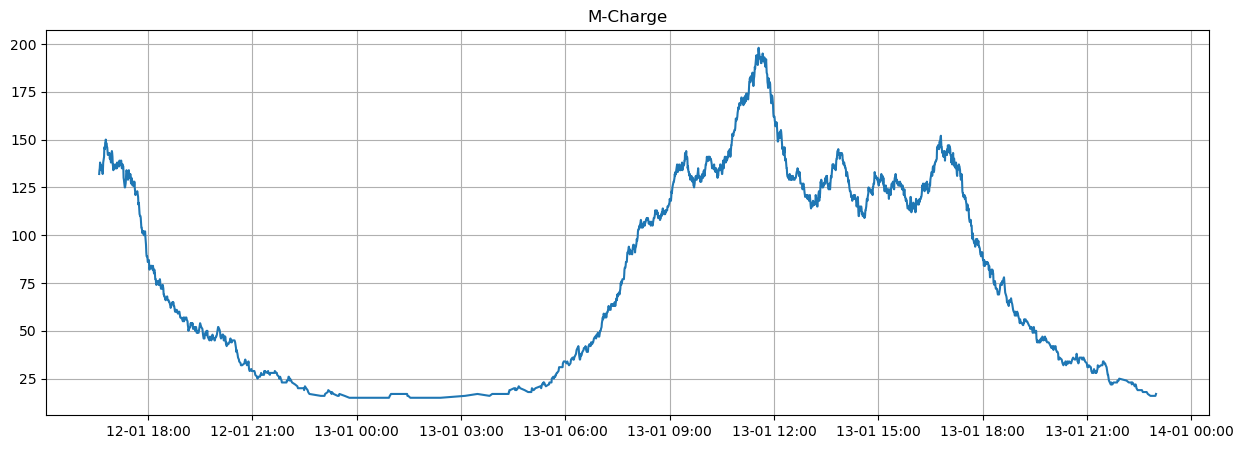

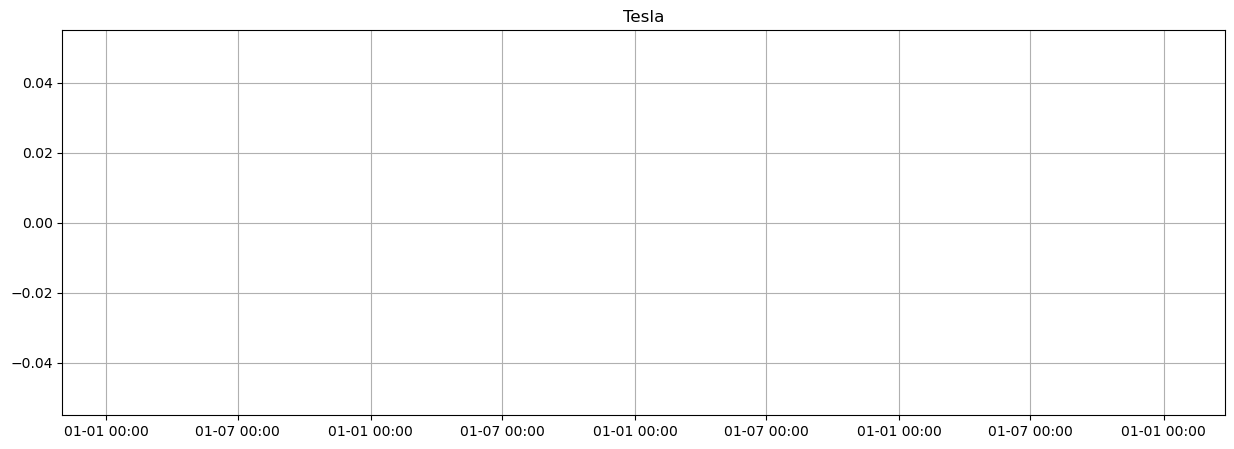

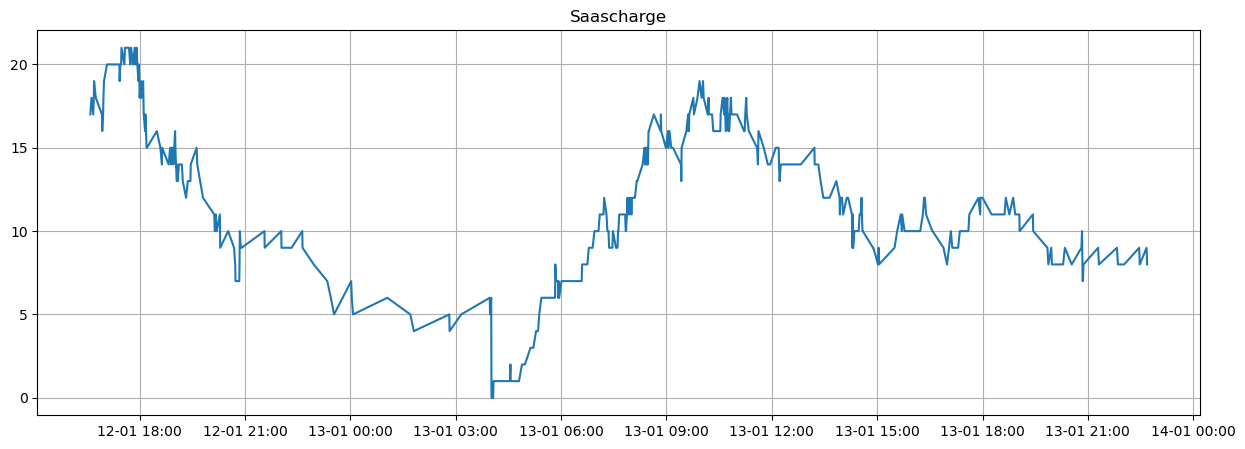

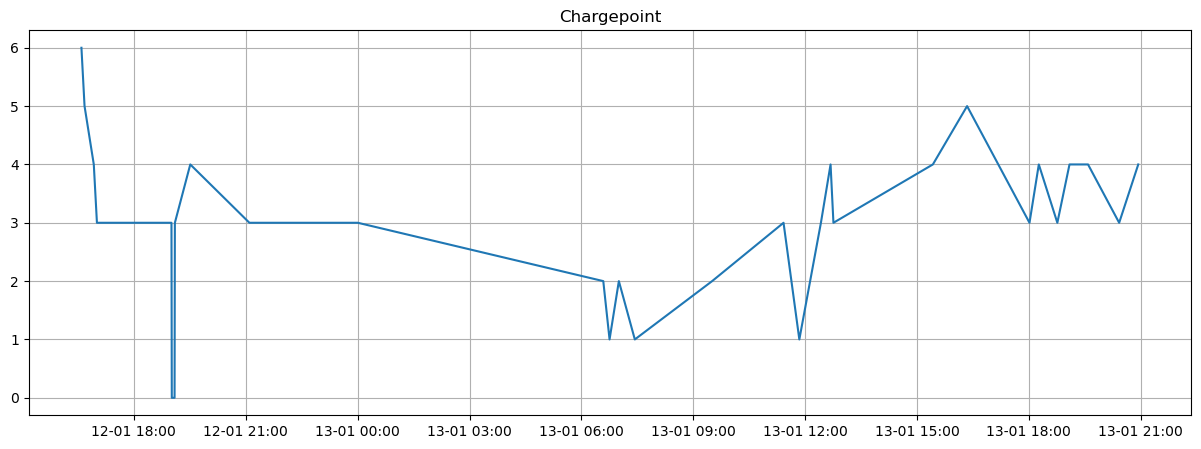

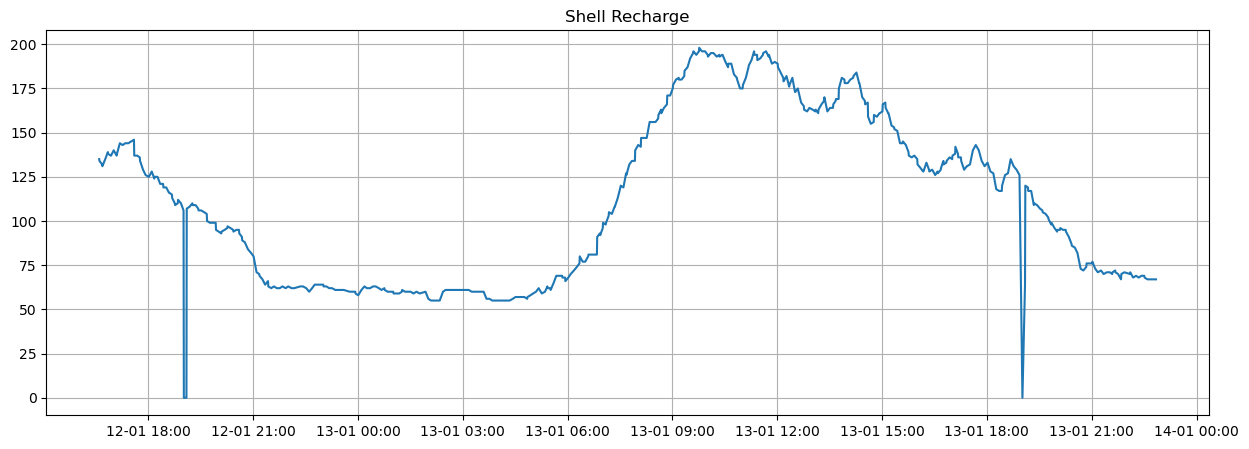

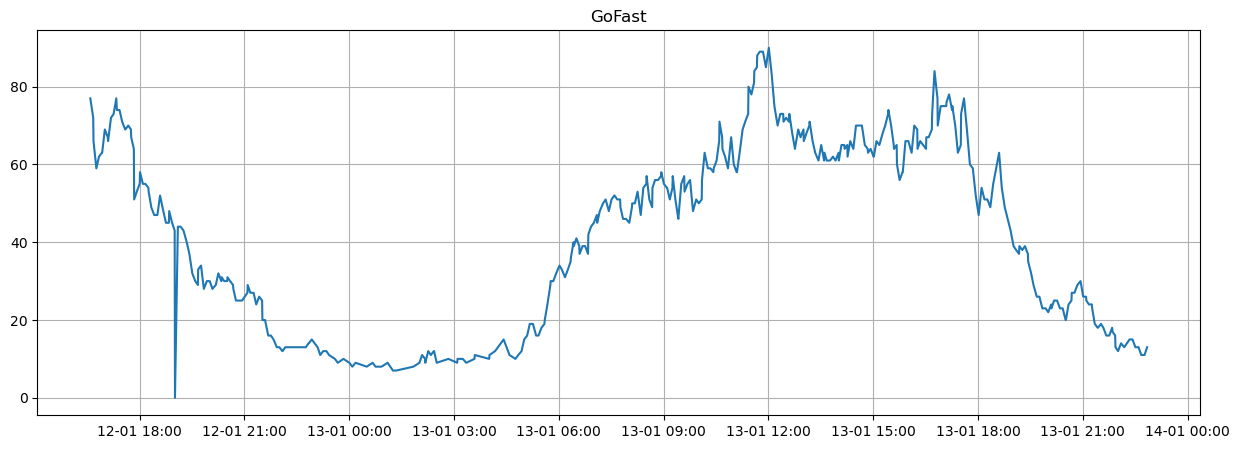

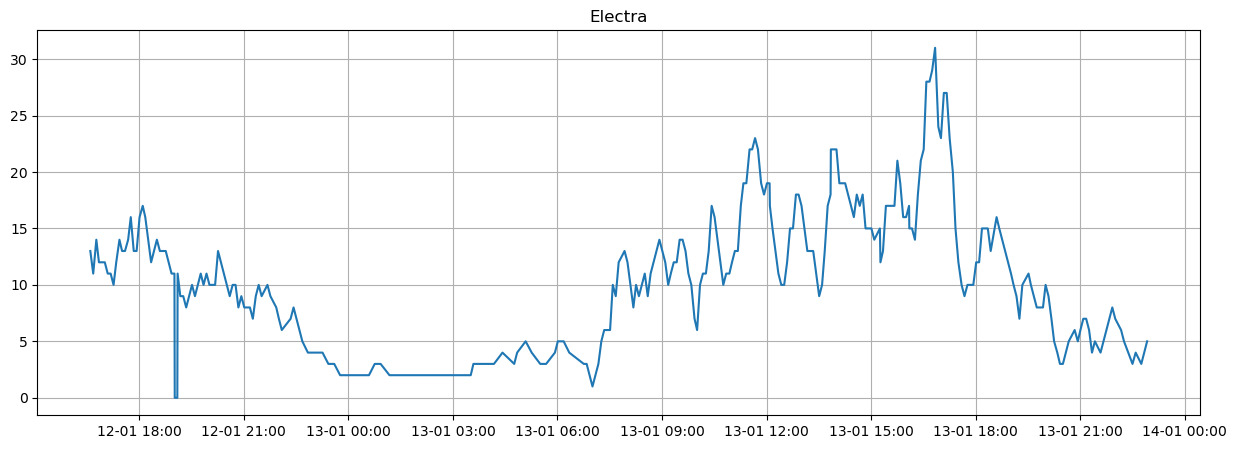

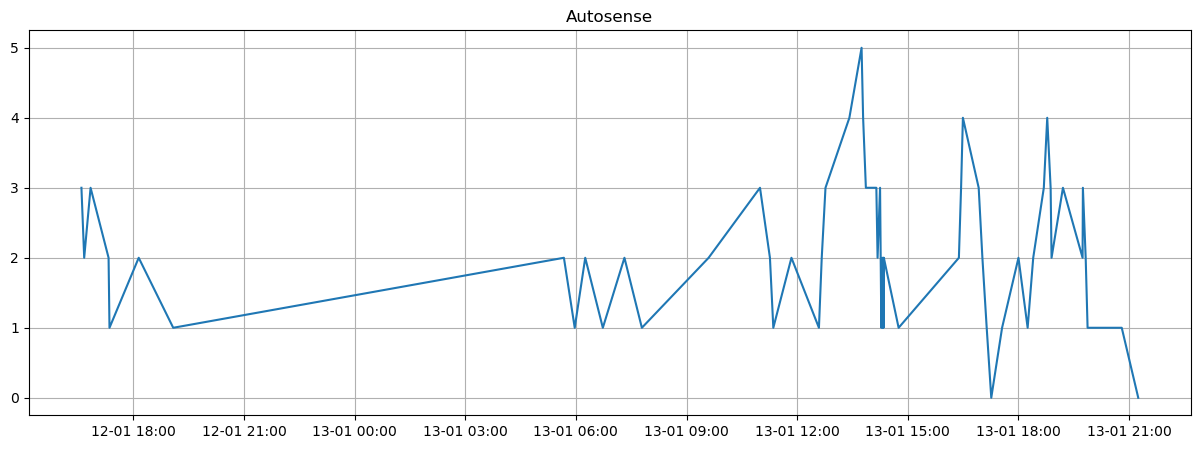

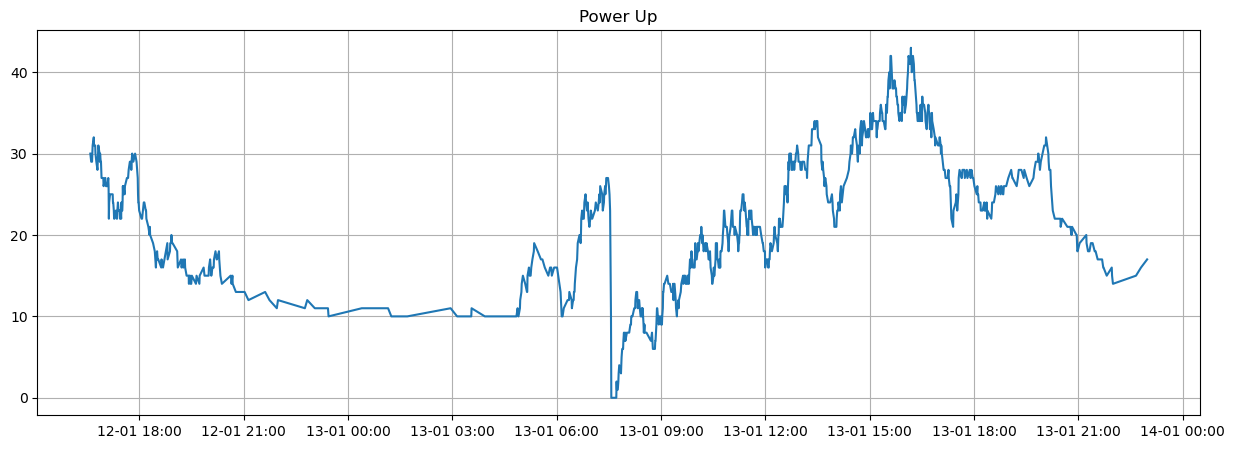

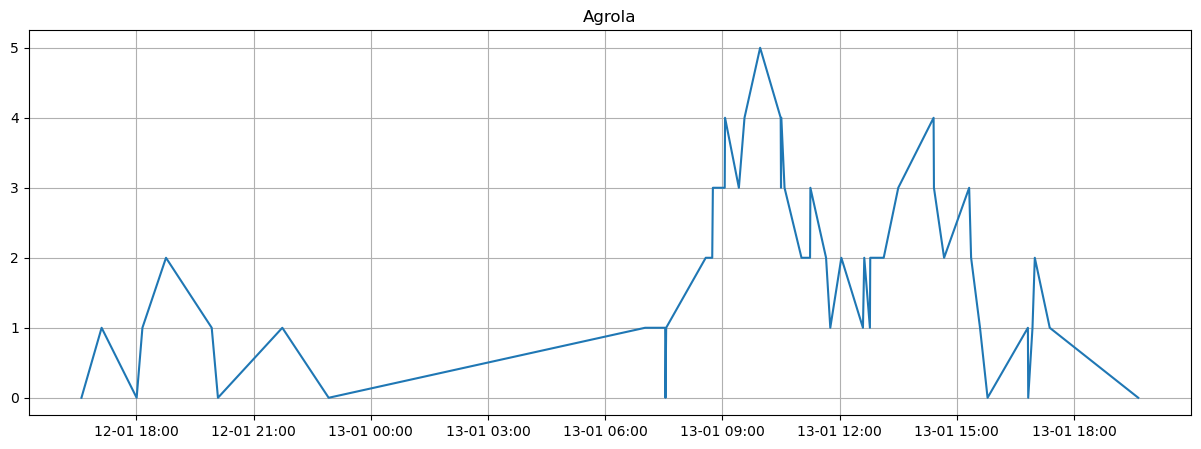

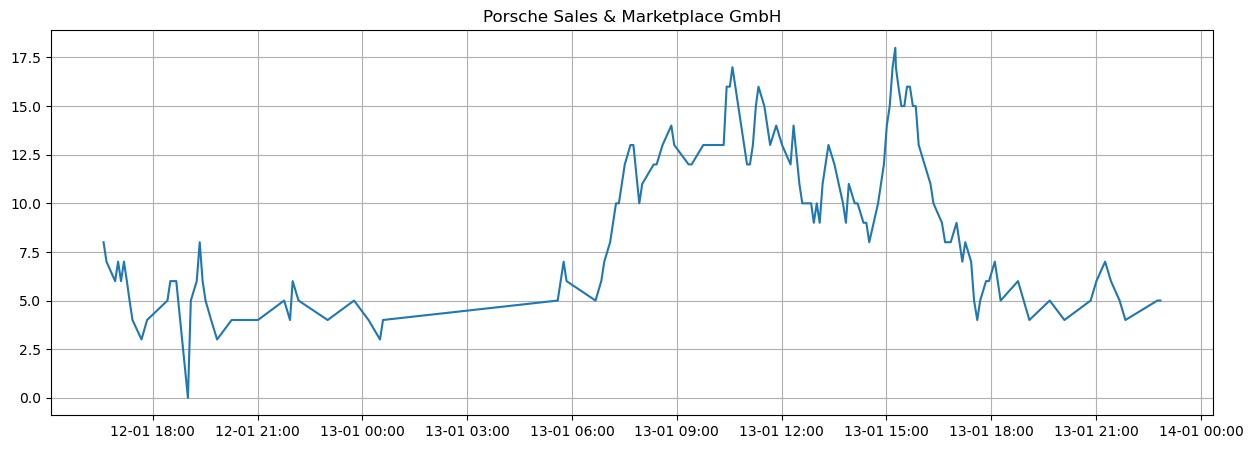

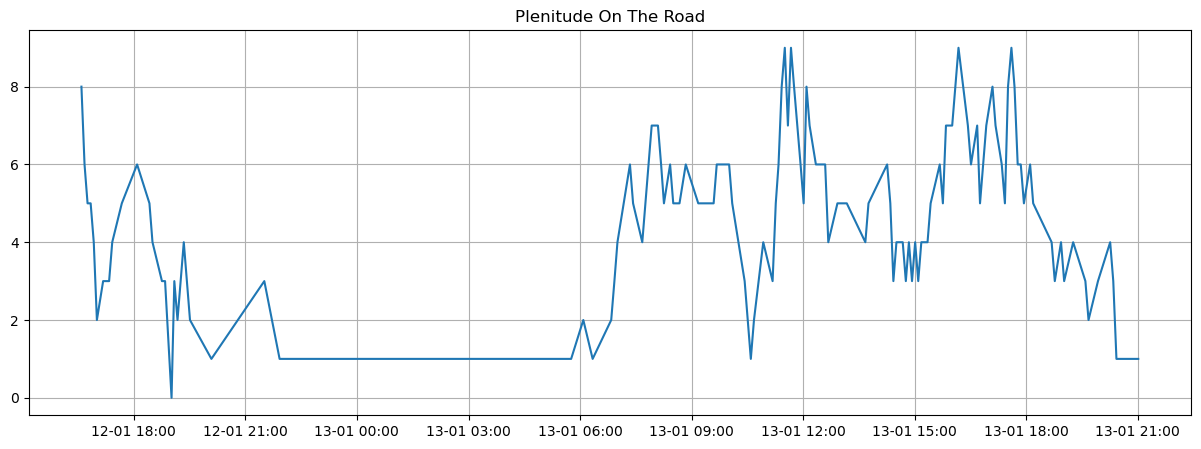

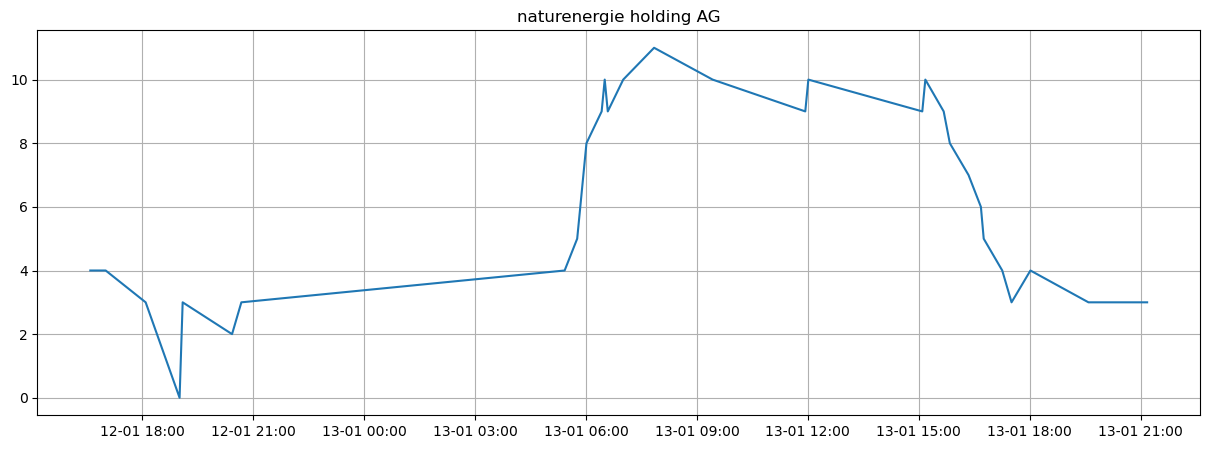

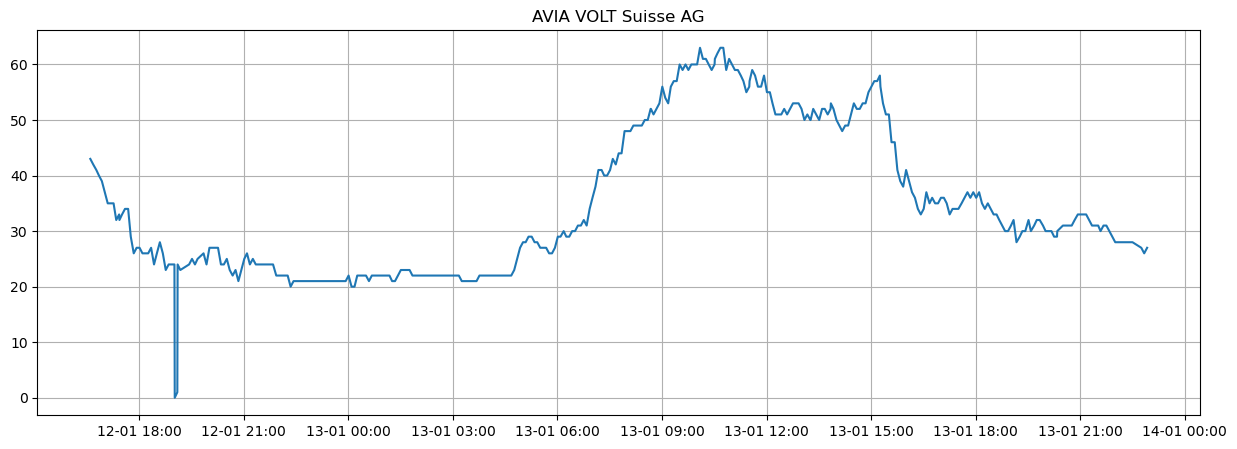

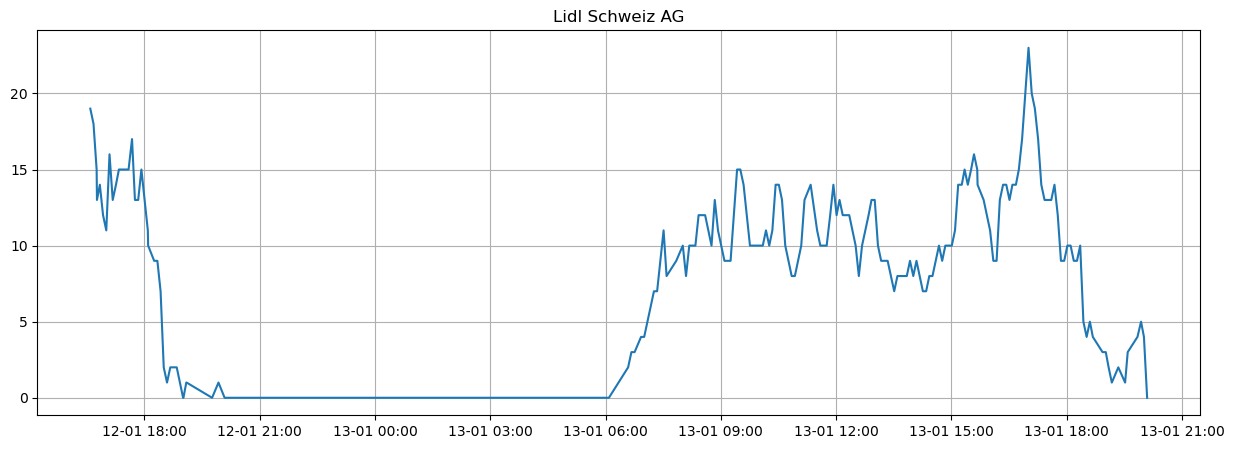

In [ ]:
for operator_id, operator_name in ser_operators.items():
    points = df_stations.query('Operator == @operator_id')['EvseID']

    occupied_count = (
        df_charge[df_charge['STATION_ID'].isin(points)]
        .groupby("TIME")['delta']
        .sum()
        .cumsum()
    )
    plt.figure(figsize=(15, 5))
    plt.plot(occupied_count)
    plt.title(operator_name)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    plt.grid()

In [ ]:
# Swisscharge status always unknown?
points_sc = df_stations.query('Operator == "CH*SWISSCHARGE"')['EvseID']
df_charge_sc = df_charge[df_charge['STATION_ID'].isin(points_sc)]
df_charge_sc['STATUS'].value_counts()

STATUS
Unknown    3985
Name: count, dtype: int64